<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Sine_Wave_Audio_Signal_Lollipop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Lookup table successfully saved to 'sine_wave_lut.csv'.


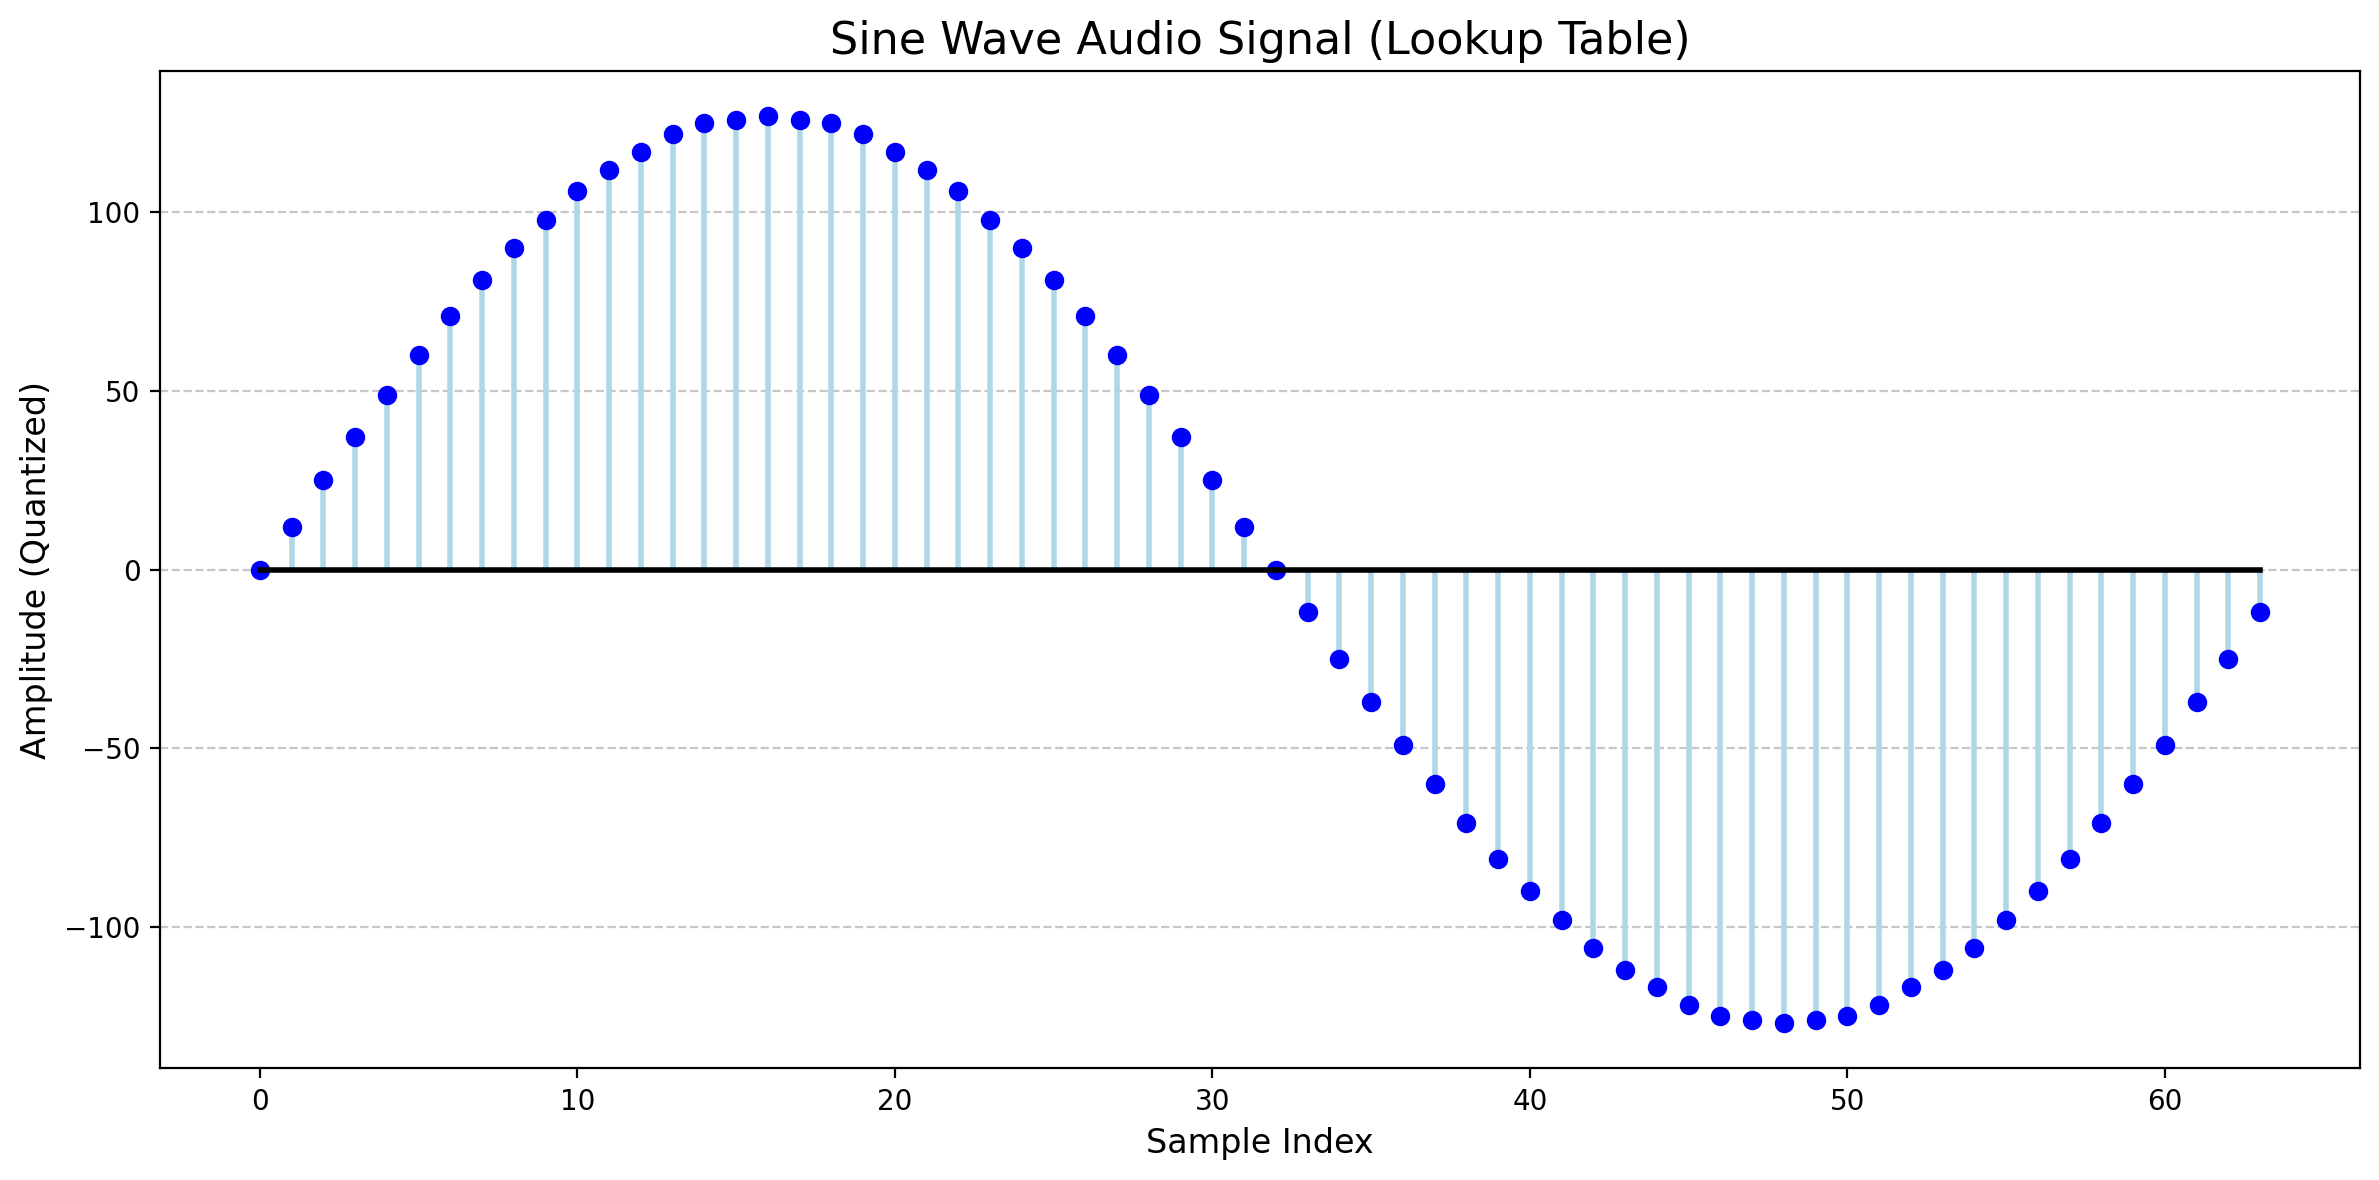

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 200

def generate_sine_lut(num_points: int = 64, amplitude: int = 127) -> pd.DataFrame:
    """
    Generate a lookup table (LUT) for a sine wave audio signal.

    This function calculates a discrete set of points representing a sine wave,
    quantizing the amplitude values to integers suitable for digital audio or
    microcontroller lookup tables.

    Args:
        num_points (int): The number of discrete samples in one full cycle of
                          the sine wave. Defaults to 64.
        amplitude (int): The peak amplitude of the sine wave (e.g., 127 for
                         8-bit signed integer representation). Defaults to 127.

    Returns:
        pd.DataFrame: A pandas DataFrame containing three columns: 'Index',
                      'Angle_rad' (angle in radians), and 'Sine_Value'
                      (quantized integer amplitude).
    """
    # Generate linear spacing for the angles from 0 to 2*pi
    angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)

    # Calculate the sine wave and quantize to integers
    sine_values = np.round(amplitude * np.sin(angles)).astype(int)

    # Create a DataFrame for the lookup table
    lut_df = pd.DataFrame({
        'Index': np.arange(num_points),
        'Angle_rad': angles,
        'Sine_Value': sine_values
    })

    return lut_df

def plot_lollipop_chart(lut_df: pd.DataFrame) -> None:
    """
    Render an inline lollipop (stem) chart from a sine wave lookup table.

    A lollipop chart is ideal for visualizing discrete, sampled signals
    such as digital audio data.

    Args:
        lut_df (pd.DataFrame): The lookup table DataFrame. Must contain
                               'Index' and 'Sine_Value' columns.
    """
    plt.figure(figsize=(12, 6))

    # Create the stem plot (lollipop chart)
    markerline, stemlines, baseline = plt.stem(
        lut_df['Index'],
        lut_df['Sine_Value'],
        basefmt="k-"
    )

    # Apply styling for visual clarity
    plt.setp(markerline, markersize=6, color='blue')
    plt.setp(stemlines, color='lightblue', linewidth=2)
    plt.setp(baseline, linewidth=2)

    plt.title('Sine Wave Audio Signal (Lookup Table)', fontsize=16)
    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel('Amplitude (Quantized)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Ensure labels and title fit well
    plt.tight_layout()

    # Display the plot inline in Colab/Jupyter
    plt.show()

if __name__ == '__main__':
    # 1. Generate the Lookup Table (64 points, max amplitude 127)
    lut_data = generate_sine_lut(num_points=64, amplitude=127)

    # 2. Export the LUT to a CSV file (optional, but helpful for reference)
    lut_data.to_csv('sine_wave_lut.csv', index=False)
    print("Lookup table successfully saved to 'sine_wave_lut.csv'.")

    # 3. Render the lollipop chart inline
    plot_lollipop_chart(lut_data)

In [2]:
from IPython.display import display, Markdown
import pandas as pd

def display_markdown_table(df: pd.DataFrame, num_rows: int = 20) -> None:
    """
    Renders a pandas DataFrame as a Markdown table in a Jupyter/Colab environment.

    Args:
        df (pd.DataFrame): The DataFrame to render.
        num_rows (int): The number of top rows to display. Defaults to 10.
    """
    # Convert the top 'num_rows' to a Markdown formatted string
    md_string = df.head(num_rows).to_markdown(index=False)

    # Display the rendered Markdown in the cell output
    display(Markdown(md_string))

# Assuming 'lut_data' is your generated sine wave DataFrame
display_markdown_table(lut_data)

|   Index |   Angle_rad |   Sine_Value |
|--------:|------------:|-------------:|
|       0 |   0         |            0 |
|       1 |   0.0981748 |           12 |
|       2 |   0.19635   |           25 |
|       3 |   0.294524  |           37 |
|       4 |   0.392699  |           49 |
|       5 |   0.490874  |           60 |
|       6 |   0.589049  |           71 |
|       7 |   0.687223  |           81 |
|       8 |   0.785398  |           90 |
|       9 |   0.883573  |           98 |
|      10 |   0.981748  |          106 |
|      11 |   1.07992   |          112 |
|      12 |   1.1781    |          117 |
|      13 |   1.27627   |          122 |
|      14 |   1.37445   |          125 |
|      15 |   1.47262   |          126 |
|      16 |   1.5708    |          127 |
|      17 |   1.66897   |          126 |
|      18 |   1.76715   |          125 |
|      19 |   1.86532   |          122 |

### Below is an interactive version of the lookup table

In [3]:
# Load Colab's interactive data table extension
%load_ext google.colab.data_table

# Display the entire LUT interactively
lut_data

# Note: To turn this feature off later, you can run:
# %unload_ext google.colab.data_table

,Index,Angle_rad,Sine_Value
0,0,0.000000,0
1,1,0.098175,12
2,2,0.196350,25
3,3,0.294524,37
4,4,0.392699,49
...,...,...,...
59,59,5.792311,-60
60,60,5.890486,-49
61,61,5.988661,-37
62,62,6.086836,-25
